In [ ]:
import pandas as pd
# https://pandas.pydata.org/docs/user_guide/

import numpy as np

# Pandas Series

### From Dictionary

In [ ]:
cities_temp = {'chennai': 25, 'bangalore': 20, 'hyderabad': 30}
cities_series = pd.Series(cities_temp)
cities_series

chennai      25
bangalore    20
hyderabad    30
dtype: int64

In [ ]:
cities_series.index

Index(['chennai', 'bangalore', 'hyderabad'], dtype='object')

In [ ]:
cities_series.values

array([25, 20, 30])

In [ ]:
# Access/locate elements by their labels like in dictionary
cities_series.loc['bangalore']

20

In [ ]:
# Access/locate elements by their position like in list
cities_series.iloc[1]

20

## List to Series

In [ ]:
ages = [20, 40, 50, 60]
ages_series = pd.Series(ages)
ages_series

0    20
1    40
2    50
3    60
dtype: int64

In [ ]:
print(ages_series.loc[0])
print(ages_series.iloc[0])

20
20


In [ ]:
print(ages_series.shape) # (No. of elements, )
print(len(ages_series))

(4,)
4


In [ ]:
ages_series.dtypes

dtype('int64')

In [ ]:
ages_series.describe()

count     4.000000
mean     42.500000
std      17.078251
min      20.000000
25%      35.000000
50%      45.000000
75%      52.500000
max      60.000000
dtype: float64

In [ ]:
cities = pd.Series(['chennai', 'bangalore', 'chennai', 'bangalore', 'hyd', 'mumbai'])
cities.describe()

count           6
unique          4
top       chennai
freq            2
dtype: object

In [ ]:
cities.dtypes

dtype('O')

# Pandas DataFrame

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/odi-batting.csv'
odi = pd.read_csv(url)
odi.shape

(55926, 8)

In [ ]:
nrows = odi.shape[0]
nrows

55926

In [ ]:
column_names = odi.columns.to_list()
column_names

['Country',
 'Player',
 'Runs',
 'ScoreRate',
 'MatchDate',
 'Ground',
 'Versus',
 'URL']

In [ ]:
odi.head()

,Country,Player,Runs,ScoreRate,MatchDate,Ground,Versus,URL
0,Afghanistan,Mohammad Shahzad,118.0,97.52,2-16-2010,Sharjah CA Stadium,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3087
1,Afghanistan,Mohammad Shahzad,110.0,99.09,9-1-2009,VRA Ground,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3008
2,Afghanistan,Mohammad Shahzad,100.0,138.88,8-16-2010,Cambusdoon New Ground,Scotland,../Matches/MatchScorecard_ODI.asp?MatchCode=3164
3,Afghanistan,Mohammad Shahzad,82.0,75.92,7-10-2010,Hazelaarweg,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3153
4,Afghanistan,Mohammad Shahzad,57.0,100.00,7-1-2010,Sportpark Westvliet,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3135


In [ ]:
# sqlalchemy, pyodbc
# host, ip address, username, psswd, dns

In [ ]:
# connection =  
# pd.read_sql('select * from odi where Player is "Ashish"', connection)
# read_sql, read_json, read_html, 

## Summary statistics of a data frame

In [ ]:
num_cols = ['Runs', 'ScoreRate']
odi[num_cols].describe()

,Runs,ScoreRate
count,55900.000000,55900.000000
mean,22.241413,65.314208
std,25.558363,44.213423
min,0.000000,0.000000
25%,4.000000,37.500000
50%,13.000000,62.660000
75%,32.000000,87.500000
max,200.000000,600.000000


In [ ]:
odi['Player'].nunique() # Number of unique values in a series

1936

In [ ]:
#odi['Country'].nunique()

In [ ]:
#odi['Country'].unique() # the unique value

In [ ]:
cat_cols = ['Country', 'Player', 'Versus', 'Ground']
odi[cat_cols].describe()

,Country,Player,Versus,Ground
count,55926,55926,55926,55926
unique,22,1936,25,178
top,India,Sachin R Tendulkar,Australia,Sharjah CA Stadium
freq,6634,442,7216,3581


In [ ]:
odi.describe(include=object)

,Country,Player,MatchDate,Ground,Versus,URL
count,55926,55926,55926,55926,55926,55926
unique,22,1936,2757,178,25,3209
top,India,Sachin R Tendulkar,2-4-2007,Sharjah CA Stadium,Australia,../Matches/MatchScorecard_ODI.asp?MatchCode=2612
freq,6634,442,108,3581,7216,22


## Frequency analysis

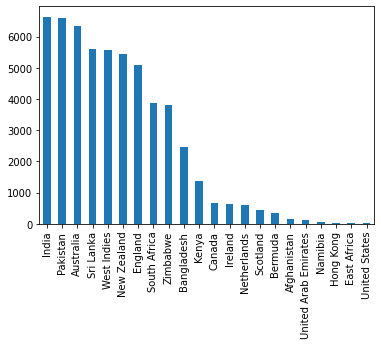

In [ ]:
# value_counts - Frequency of each unique elements in a series
odi['Country'].value_counts().plot.bar();

## Grouping

In [ ]:
df_marks = pd.DataFrame({
    'name': ['a', 'a','a', 'b', 'b'],
    'subject': ['lang', 'math', 'science', 'lang', 'math'],
    'marks': [40, 50, 20, 50, 35]
})
df_marks

,name,subject,marks
0,a,lang,40
1,a,math,50
2,a,science,20
3,b,lang,50
4,b,math,35


In [ ]:
#new_df = df.groupby([cols_to_groups]).agg(new_col_name1=('old_col_name', 'agg_func'),
#                                          new_col_name2=('old_col_name', 'agg_func'))

In [ ]:
# Studentwise total marks
summary = df_marks.groupby(['name']).agg(Total_Marks=('marks', 'sum'),
                                         Avg_Marks=('marks', 'mean'))
summary

,Total_Marks,Avg_Marks
name,,
a,110,36.666667
b,85,42.500000


In [ ]:
#df.drop_duplicates()

In [ ]:
# Compute Playerwise total runs, avg runs, avg score rate, total matches using odi

summary = odi.groupby(['Player']).agg(Total_Runs=('Runs', 'sum'),
                                      Avg_Runs=('Runs', 'mean'),
                                      Avg_ScoreRate=('ScoreRate', 'mean'),
                                      Total_Matches=('Country', 'count'))
summary = summary.sort_values(by=['Total_Matches','Total_Runs'],
                              ascending=False)
summary.head()

,Total_Runs,Avg_Runs,Avg_ScoreRate,Total_Matches
Player,,,,
Sachin R Tendulkar,18111.0,40.975113,74.612127,442
Sanath T Jayasuriya,13430.0,31.016166,77.577506,433
Ricky T Ponting,13686.0,38.016667,69.831194,360
Inzamam-ul-Haq,11739.0,33.540000,67.453114,351
D P Mahela Jayawardene,9913.0,30.039394,65.058697,330


In [ ]:
## "Total_Runs" for "Sachin R Tendulkar"
summary.loc['Sachin R Tendulkar', 'Total_Runs']

18111.0

## Exercise using employees data
- Identify `JobRole` wise
  - number of employees
  - their average `MonthlyIncome`
  - Average `Age`
- Sort the results based on descending order of number of employees
- Print the jobrole which has the maximum employees (i.e. first row, first column)

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/employees_attrition.csv'
employees = pd.read_csv(url)
employees.shape

(1470, 35)

In [ ]:
summary = employees.groupby(['JobRole']).agg(Employees_Count=('Age', 'count'),
                                             Avg_Monthly_Income=('MonthlyIncome', 'mean'),
                                             Avg_Age=('Age', 'mean')).sort_values(
                                                 by=['Employees_Count'],
                                                 ascending=False
                                             )
summary

,Employees_Count,Avg_Monthly_Income,Avg_Age
JobRole,,,
Sales Executive,326,6924.279141,36.889571
Research Scientist,292,3239.972603,34.236301
Laboratory Technician,259,3237.169884,34.096525
Manufacturing Director,145,7295.137931,38.296552
Healthcare Representative,131,7528.763359,39.809160
Manager,102,17181.676471,46.764706
Sales Representative,83,2626.000000,30.361446
Research Director,80,16033.550000,44.000000
Human Resources,52,4235.750000,35.500000


In [ ]:
# Access first row and first column in the previous result
summary.iloc[0,0]

326

## Apply Methods

In [ ]:
calc_is_century = lambda run: 1 if run > 99 else 0
odi['is_century'] = odi['Runs'].apply(calc_is_century)
odi['is_duck'] = odi['Runs'].apply(lambda run: 1 if run == 0 else 0)
odi['is_fifty'] = odi['Runs'].apply(lambda run: 1 if run>49 and run<100 else 0)
odi['is_missed_century'] = odi['Runs'].apply(lambda run: 1 if run>90 and run<100 else 0)
cols = ['Runs', 'is_century', 'is_duck', 'is_fifty', 'is_missed_century']
odi[cols].head()

,Runs,is_century,is_duck,is_fifty,is_missed_century
0,118.0,1,0,0,0
1,110.0,1,0,0,0
2,100.0,1,0,0,0
3,82.0,0,0,1,0
4,57.0,0,0,1,0


In [ ]:
summary = odi.groupby(['Player']).agg(Total_Runs=('Runs', 'sum'),
                                      Avg_Runs=('Runs', 'mean'),
                                      Avg_ScoreRate=('ScoreRate', 'mean'),
                                      Total_Matches=('Country', 'count'),
                                      Total_Centuries=('is_century', 'sum'),
                                      Total_Fifties=('is_fifty', 'sum'),
                                      Total_Ducks=('is_duck', 'sum'),
                                      Total_Missed_Centuries=('is_missed_century', 'sum'))
summary = summary.sort_values(by=['Total_Matches','Total_Runs'],
                              ascending=False)
summary.head()

,Total_Runs,Avg_Runs,Avg_ScoreRate,Total_Matches,Total_Centuries,Total_Fifties,Total_Ducks,Total_Missed_Centuries
Player,,,,,,,,
Sachin R Tendulkar,18111.0,40.975113,74.612127,442,48,95,20,17
Sanath T Jayasuriya,13430.0,31.016166,77.577506,433,28,68,34,6
Ricky T Ponting,13686.0,38.016667,69.831194,360,30,82,20,5
Inzamam-ul-Haq,11739.0,33.540000,67.453114,351,10,83,20,2
D P Mahela Jayawardene,9913.0,30.039394,65.058697,330,15,60,26,3


## Multi-index

In [ ]:
summary = employees.groupby(['MaritalStatus', 'Gender']).agg(Avg_Income=('MonthlyIncome', 'mean'),
                                               Employees_Count=('Age', 'count'))
summary

Avg_Income  Employees_Count
MaritalStatus Gender                              
Divorced      Female  6769.324786              117
              Male    6795.738095              210
Married       Female  7156.970588              272
              Male    6547.244389              401
Single        Female  5994.944724              199
              Male    5812.022140              271

In [ ]:
summary.index

MultiIndex([('Divorced', 'Female'),
            ('Divorced',   'Male'),
            ( 'Married', 'Female'),
            ( 'Married',   'Male'),
            (  'Single', 'Female'),
            (  'Single',   'Male')],
           names=['MaritalStatus', 'Gender'])

In [ ]:
summary.columns

Index(['Avg_Income', 'Employees_Count'], dtype='object')

In [ ]:
print(summary.loc[('Divorced', 'Female'), 'Avg_Income'])
print(summary.loc[('Single', 'Male'), 'Avg_Income'])

6769.324786324786
5812.022140221402


## Reset Index
- Move variable from index to column

In [ ]:
summary = employees.groupby(['MaritalStatus', 'Gender']).agg(Avg_Income=('MonthlyIncome', 'mean'),
                                               Employees_Count=('Age', 'count'))
summary = summary.reset_index()
summary

,MaritalStatus,Gender,Avg_Income,Employees_Count
0,Divorced,Female,6769.324786,117
1,Divorced,Male,6795.738095,210
2,Married,Female,7156.970588,272
3,Married,Male,6547.244389,401
4,Single,Female,5994.944724,199
5,Single,Male,5812.022140,271


In [ ]:
summary.columns

Index(['MaritalStatus', 'Gender', 'Avg_Income', 'Employees_Count'], dtype='object')

## Date operations

In [ ]:
odi.head()

,Country,Player,Runs,ScoreRate,MatchDate,Ground,Versus,URL,is_century,is_duck,is_fifty,is_missed_century
0,Afghanistan,Mohammad Shahzad,118.0,97.52,2-16-2010,Sharjah CA Stadium,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3087,1,0,0,0
1,Afghanistan,Mohammad Shahzad,110.0,99.09,9-1-2009,VRA Ground,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3008,1,0,0,0
2,Afghanistan,Mohammad Shahzad,100.0,138.88,8-16-2010,Cambusdoon New Ground,Scotland,../Matches/MatchScorecard_ODI.asp?MatchCode=3164,1,0,0,0
3,Afghanistan,Mohammad Shahzad,82.0,75.92,7-10-2010,Hazelaarweg,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3153,0,0,1,0
4,Afghanistan,Mohammad Shahzad,57.0,100.00,7-1-2010,Sportpark Westvliet,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3135,0,0,1,0


In [ ]:
odi['Date'] = pd.to_datetime(odi['MatchDate'], format='%m-%d-%Y')
odi['year'] = odi['Date'].dt.year
odi['month'] = odi['Date'].dt.month

In [ ]:
# Filter for Sachin R Tendulkar and compute yearwise total runs
# select * from odi where Player is "Sachin R Tendulkar"
sachin = odi[odi['Player'] == 'Sachin R Tendulkar']
sachin.shape

(442, 15)

In [ ]:
# Filter for Sachin R Tendulkar and compute yearwise total runs
# Sort the results based on total runs
# and identify the year in which he has scored maximum runs

In [ ]:
sachin = odi[odi['Player'] == 'Sachin R Tendulkar']
yearwise_runs = sachin.groupby('year').agg(Total_Runs=('Runs', 'sum'))
yearwise_runs = yearwise_runs.sort_values(by='Total_Runs', ascending=False)
yearwise_runs.index[0]

1998

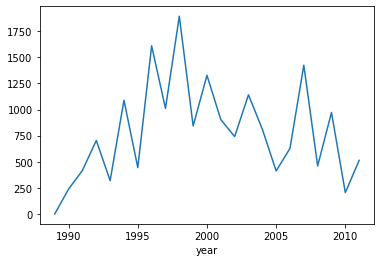

In [ ]:
sachin = odi[odi['Player'] == 'Sachin R Tendulkar']
yearwise_runs = sachin.groupby('year').agg(Total_Runs=('Runs', 'sum'))
yearwise_runs['Total_Runs'].plot.line();

## Pivot 

In [ ]:
# JobRole wise, Department wise average monthly Income

In [ ]:
summary = employees.pivot_table(index='JobRole',
                                columns='Department',
                                values='MonthlyIncome',
                                aggfunc='mean')
summary

Department,Human Resources,Research & Development,Sales
JobRole,,,
Healthcare Representative,NaN,7528.763359,NaN
Human Resources,4235.750000,NaN,NaN
Laboratory Technician,NaN,3237.169884,NaN
Manager,18088.636364,17130.333333,16986.972973
Manufacturing Director,NaN,7295.137931,NaN
Research Director,NaN,16033.550000,NaN
Research Scientist,NaN,3239.972603,NaN
Sales Executive,NaN,NaN,6924.279141
Sales Representative,NaN,NaN,2626.000000


In [ ]:
## Using odi dataset
# Identify playerwise (rows), countrywise (versus) (columns) total runs scores